#### Student Performance Indicator

##### Problem Statement:
 - this project understands how students performance affected by other parameters such as gender ethnicity ,parental level of education

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

import csv file

In [4]:
df=pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

there are no missing values

In [7]:
df.duplicated().sum()

np.int64(0)

no duplicates in the data

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [59]:
df.shape

(1000, 10)

In [20]:
for i in df.columns:
    if df[i].dtypes=='str':
        print(i)

gender
race_ethnicity
parental_level_of_education
lunch
test_preparation_course


In [17]:
categorical_cols=[i for i in df.columns if df[i].dtypes=='str']
categorical_cols

['gender',
 'race_ethnicity',
 'parental_level_of_education',
 'lunch',
 'test_preparation_course']

In [33]:
print(f"we have {len(categorical_cols)} numerical features : {categorical_cols}")

we have 5 numerical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [21]:
numerical_cols=[i for i in df.columns if df[i].dtypes!='str']
numerical_cols

['math_score', 'reading_score', 'writing_score']

In [32]:
print(f"we have {len(numerical_cols)} numerical features : {numerical_cols}")

we have 3 numerical features : ['math_score', 'reading_score', 'writing_score']


unique values of categorical columns

In [27]:
for i in categorical_cols:
    print(f"column: {i}")
    print(df[i].unique())
    print("-"*20)
    print()

column: gender
<StringArray>
['female', 'male']
Length: 2, dtype: str
--------------------

column: race_ethnicity
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
--------------------

column: parental_level_of_education
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
--------------------

column: lunch
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
--------------------

column: test_preparation_course
<StringArray>
['none', 'completed']
Length: 2, dtype: str
--------------------



In [ ]:
df[df['lunch']=='free/reduced']

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
3,male,group A,associate's degree,free/reduced,none,47,57,44
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50
17,female,group B,some high school,free/reduced,none,18,32,28
...,...,...,...,...,...,...,...,...
992,female,group D,associate's degree,free/reduced,none,55,76,76
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65


adding new columns to dataset i.e total score and average score

In [30]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']

df['average_score']=df['total_score']/3

how many students got full marks ( 100) in math,reading and writing

In [38]:
df[df['reading_score']==100]['average_score'].count()

np.int64(17)

In [ ]:
reading_full=df[df['reading_score']==100]['average_score'].count()
writing_full=df[df['writing_score']==100]['average_score'].count()
math_full=df[df['math_score']==100]['average_score'].count()

print(f"Number of students with full marks in Reading: {reading_full}")
print(f"Number of students with full marks in Writing: {writing_full}")
print(f"Number of students with full marks in Maths: {math_full}")

number of students with full marks in reading: 17
number of students with full marks in writing: 14
number of students with full marks in math: 7


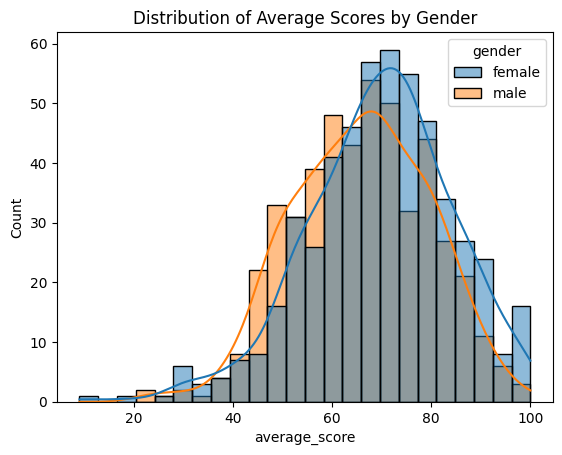

In [54]:
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.title("Distribution of Average Scores by Gender")
plt.show()

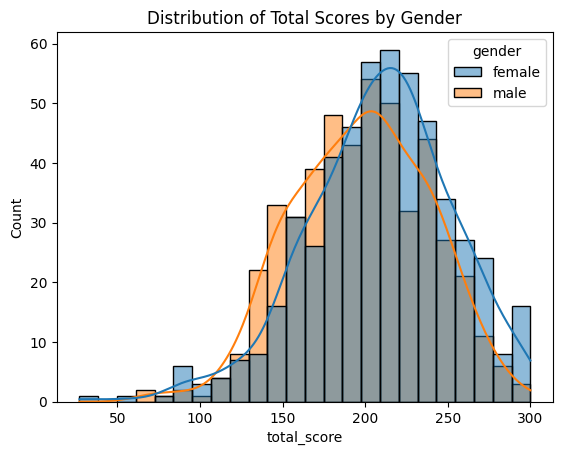

In [58]:
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.title("Distribution of Total Scores by Gender")
plt.show()

##### insights

female students tend perform well than male

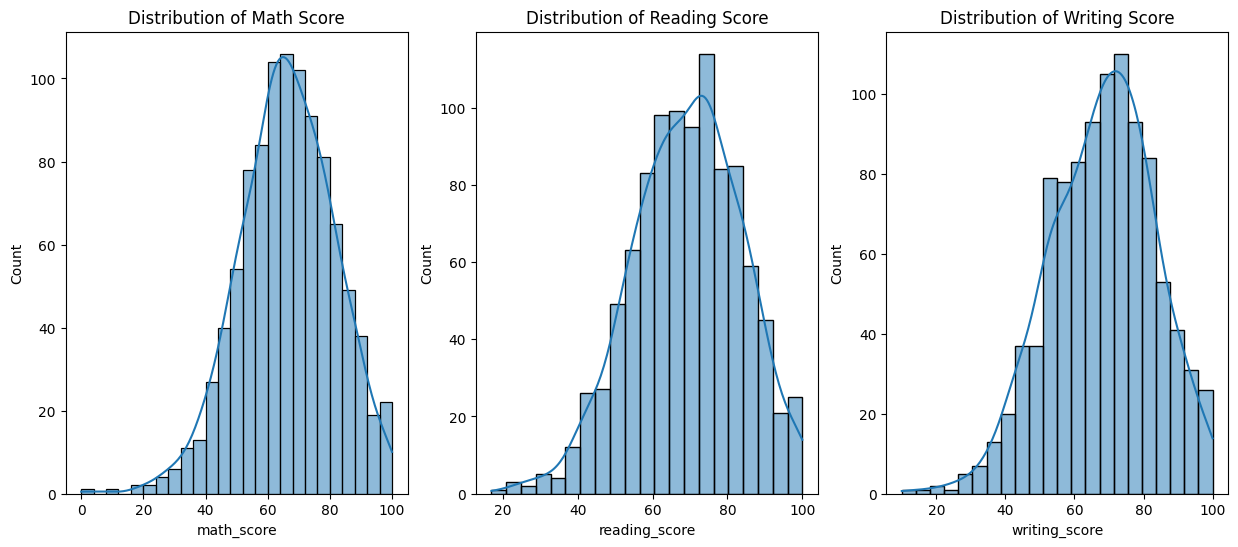

In [70]:
plt.figure(figsize=(15,6))
def plotting(col_name,position):
    plt.subplot(1,3,position)
    plt.title(f"Distribution of {col_name.replace('_',' ').title()}")
    sns.histplot(df[col_name],kde=True)

for i,col in enumerate(numerical_cols,start=1):
    plotting(col,i)

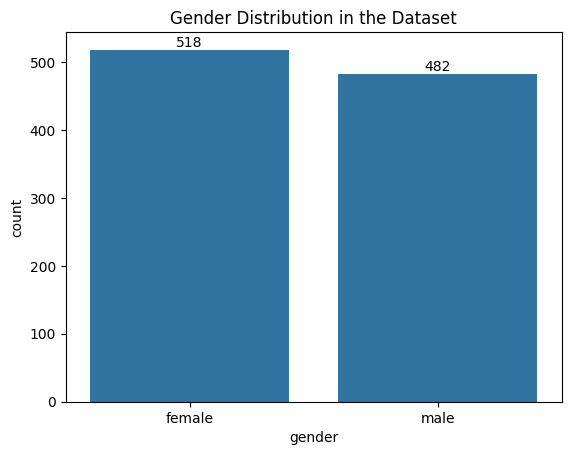

In [73]:
ax=sns.countplot(data=df,x='gender')

for bar in ax.containers:
    ax.bar_label(bar)


plt.title("Gender Distribution in the Dataset")
plt.show()

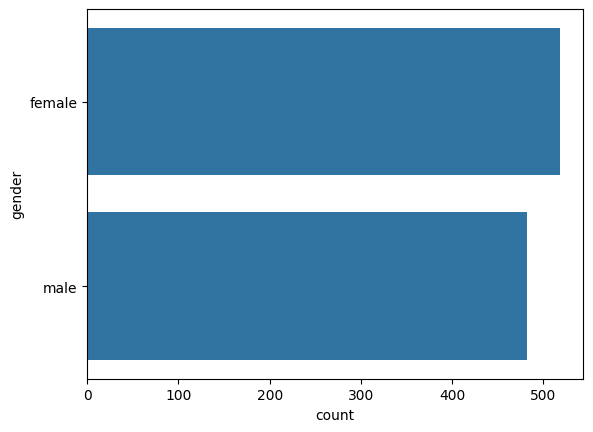

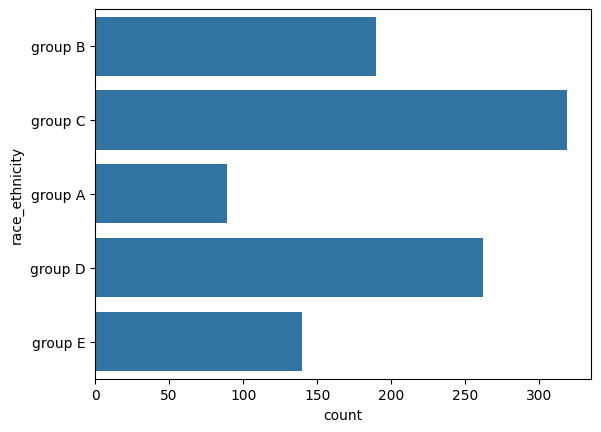

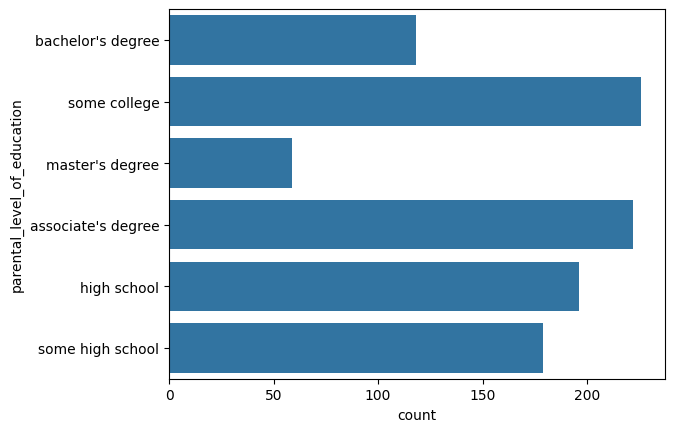

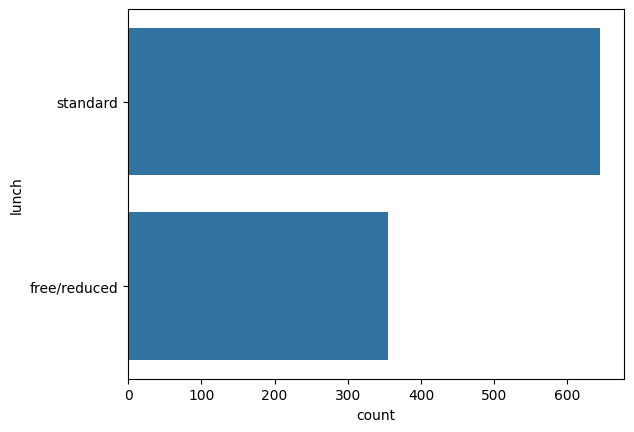

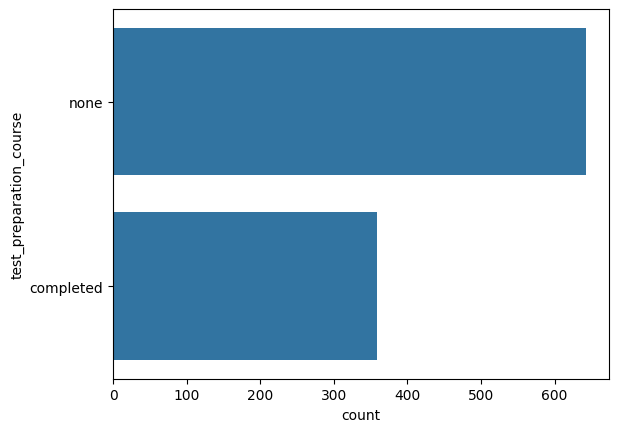

In [77]:
for i in categorical_cols:
    sns.countplot(data=df,y=i)
    plt.show()

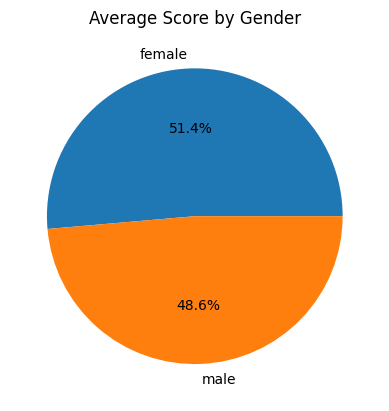

In [86]:
gb1=df.groupby('gender')['average_score'].mean().reset_index()

plt.pie(gb1['average_score'],labels=gb1['gender'],autopct='%1.1f%%')
plt.title("Average Score by Gender")
plt.show()

In [89]:
avg_math_by_prep = df.groupby('test_preparation_course')['math_score'].mean()
print(avg_math_by_prep)

test_preparation_course
completed    69.695531
none         64.077882
Name: math_score, dtype: float64


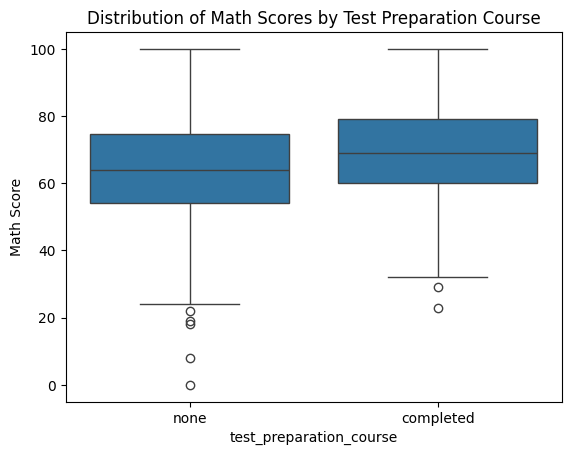

In [88]:
sns.boxplot(x='test_preparation_course', y='math_score', data=df)
plt.title("Distribution of Math Scores by Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

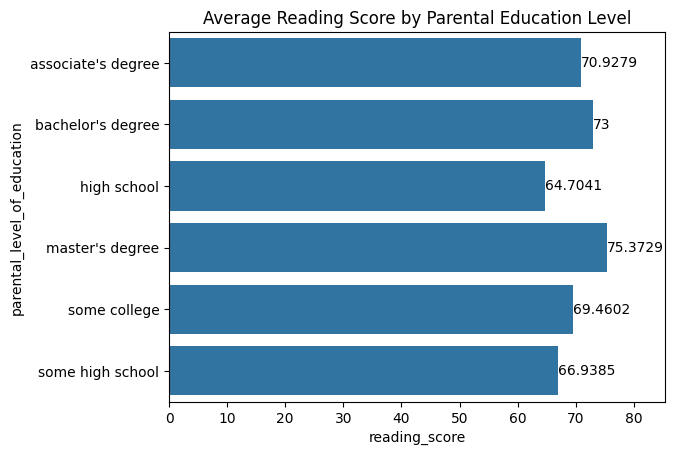

In [120]:
gb2=df.groupby('parental_level_of_education')['reading_score'].mean().reset_index()
ax=sns.barplot(data=gb2,y='parental_level_of_education',x='reading_score')

for bar in ax.containers:
    ax.bar_label(bar)
plt.title("Average Reading Score by Parental Education Level")
plt.xlim(0, gb2['reading_score'].max() + 10) 
plt.show()

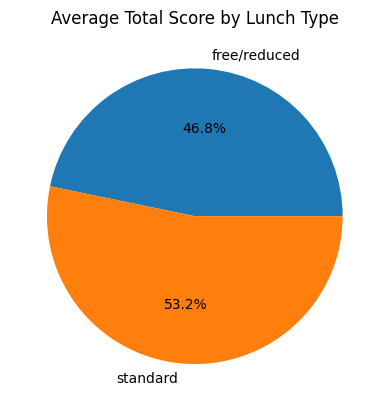

In [105]:
gb3=df.groupby('lunch')['total_score'].mean().reset_index()

plt.pie(gb3['total_score'],labels=gb3['lunch'],autopct="%1.1f%%")
plt.title("Average Total Score by Lunch Type")
plt.show()

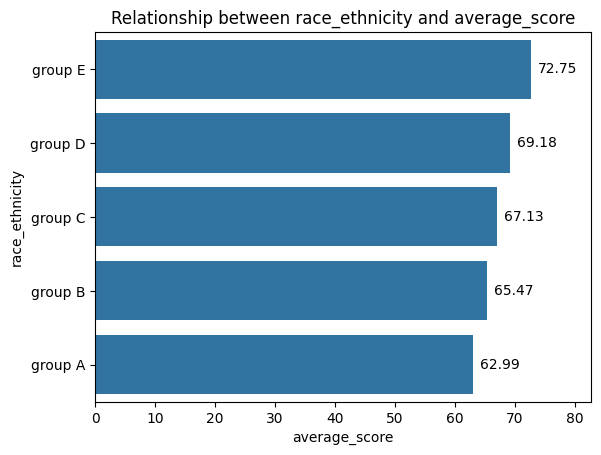

In [118]:
gb4=df.groupby('race_ethnicity')['average_score'].mean().reset_index().sort_values(by='average_score',ascending=False)

ax=sns.barplot(data=gb4,x='average_score',y='race_ethnicity')

for bar in ax.containers:
    ax.bar_label(bar, label_type='edge', padding=5, fmt='%.2f')

plt.title("Relationship between race_ethnicity and average_score")
plt.xlim(0, gb4['average_score'].max() + 10) 
plt.show()

In [123]:
df[numerical_cols].corr()

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


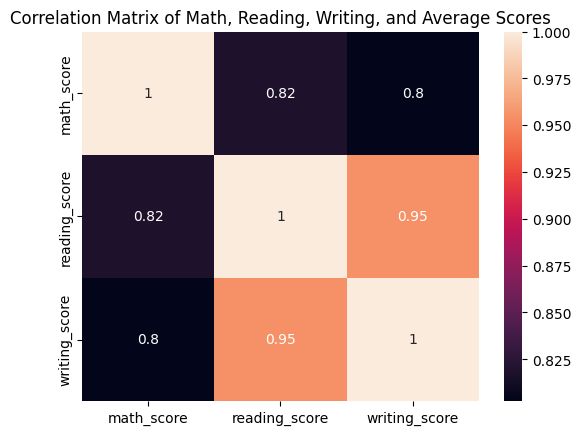

In [125]:
sns.heatmap(df[numerical_cols].corr(),annot=True)
plt.title("Correlation Matrix of Math, Reading, Writing, and Average Scores")
plt.show()

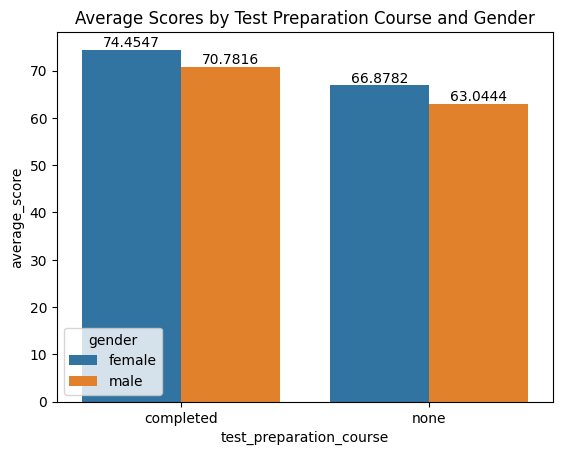

In [132]:
gb5=df.groupby(['gender','test_preparation_course'])['average_score'].mean().reset_index()

ax=sns.barplot(data=gb5,x='test_preparation_course',y='average_score',hue='gender')

for bar in ax.containers:
    ax.bar_label(bar)

plt.title("Average Scores by Test Preparation Course and Gender")
plt.show()

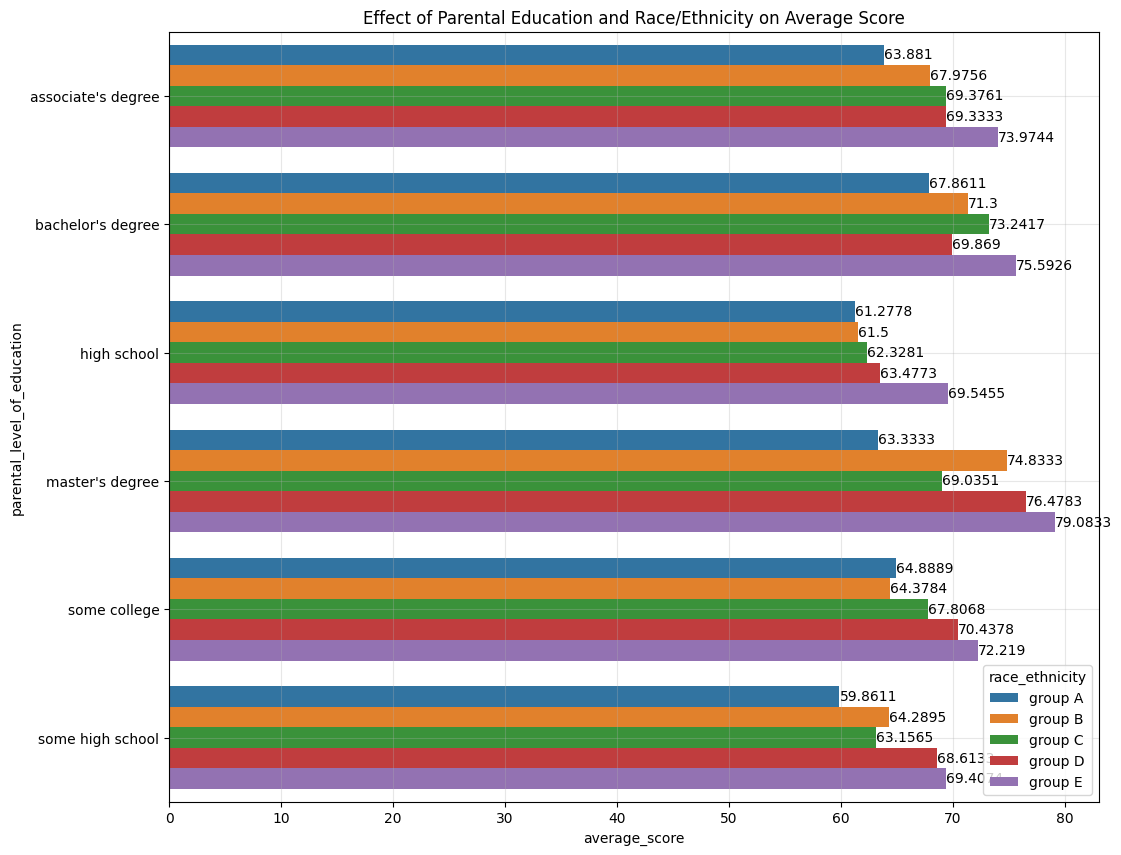

In [141]:
gb6=df.groupby(['parental_level_of_education','race_ethnicity'])['average_score'].mean().reset_index()

plt.figure(figsize=(12,10))
ax = sns.barplot(
    data=gb6,
    y='parental_level_of_education',
    x='average_score',
    hue='race_ethnicity'
)

for bar in ax.containers:
    ax.bar_label(bar)

plt.title("Effect of Parental Education and Race/Ethnicity on Average Score")
plt.grid(alpha=0.3)
plt.show()

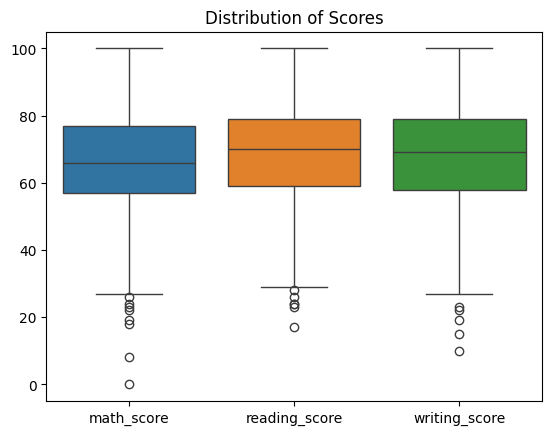

In [144]:
sns.boxplot(df[numerical_cols])
plt.title("Distribution of Scores")
plt.show()

In [31]:
df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
